In [58]:
import numpy as np
import pandas as pd
import torch
from torch import nn, optim
from torchvision import datasets, transforms, utils
from torchsummary import summary
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

plt.rcParams.update({'axes.grid': False})

**Step 1: Download and prepare the MNIST dataset**

In [29]:
BATCH_SIZE = 64

# Define the transformation for preprocessing the data
# In this case, we convert the images to PyTorch tensors
transform = transforms.Compose([transforms.ToTensor()])

# Download and load the training dataset
# train=True means we are downloading the training split of MNIST
trainset_normal = datasets.MNIST('data/', download=True, train=True, transform=transform)
validset_normal = datasets.MNIST('data/', download=True, train=False, transform=transform)

len(trainset_normal), len(validset_normal)

(60000, 10000)

In [30]:
# Create Data Loaders

trainloader_normal = torch.utils.data.DataLoader(trainset_normal, batch_size=BATCH_SIZE, shuffle=True)
validloader_normal = torch.utils.data.DataLoader(validset_normal, batch_size=BATCH_SIZE, shuffle=False) # it is common to set shuffle to False for validation to keep it clean 

print(f"Training batches:   {len(trainloader_normal)}")  # Expected:(len(trainset) / BATCH_SIZE)
print(f"Validation batches: {len(validloader_normal)}")  

Training batches:   938
Validation batches: 157


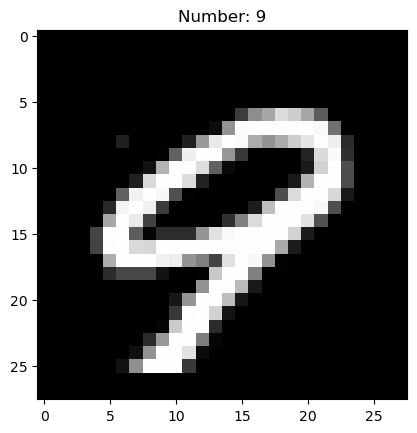

In [31]:
#visualize a sample from the training data

X, y = next(iter(trainloader_normal))
plt.imshow(X[0, 0, :, :], cmap="gray")
plt.title(f"Number: {y[0].item()}");

**Step 2: Define the CNN architecture**

In [32]:
class MNIST_classifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            #nn.Conv2d(in_channels,out_channels(how many filters to learn?),kernel_size)
            nn.Conv2d(1,16,(5,5)), #convolutional layers(feature extraction), these scan image and learn to detect features like edges,curves,and shapes 
            nn.ReLU(),
            #nn.MaxPool2d(kernel_size)
            nn.MaxPool2d((2,2)),# downsample the feature map to reduce size and computation, it keeps the Max value in each window, keeping strongest features
            nn.Dropout(0.2), # 20% of neurons randomly turned off
            nn.Flatten(),
            #nn.Linear(in_features, out_features)
            nn.Linear(2304,128), # After extracting features, we flatten everything and pass it through linear layers to produce the final predictions
            nn.ReLU(),
            nn.Linear(128,10)
        )

    def forward(self, x):
        out = self.main(x)
        return out

We'll now create an instance of the `MNIST_classifier` class and examine the parameters of each layer using the `summary` function of the `torchsummary` module imported earlier. 

In [33]:
model = MNIST_classifier()

In [34]:
summary(model, (1, 28, 28));

Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 10]                  --
|    └─Conv2d: 2-1                       [-1, 16, 24, 24]          416
|    └─ReLU: 2-2                         [-1, 16, 24, 24]          --
|    └─MaxPool2d: 2-3                    [-1, 16, 12, 12]          --
|    └─Dropout: 2-4                      [-1, 16, 12, 12]          --
|    └─Flatten: 2-5                      [-1, 2304]                --
|    └─Linear: 2-6                       [-1, 128]                 295,040
|    └─ReLU: 2-7                         [-1, 128]                 --
|    └─Linear: 2-8                       [-1, 10]                  1,290
Total params: 296,746
Trainable params: 296,746
Non-trainable params: 0
Total mult-adds (M): 0.82
Input size (MB): 0.00
Forward/backward pass size (MB): 0.07
Params size (MB): 1.13
Estimated Total Size (MB): 1.21


**Step 3: Training**

In [35]:
#Function Signatures:
# model: CNN
# criterion: the loss function (measures how wrong the model is)
# optimizer: the algorithm that updates the weights
# trainloader: batches of training data
# validloader: batches of validation data
# epochs: how many times to loop over the full dataset
# verbose: whether to print progress or not

def trainer(model, criterion, optimizer, trainloader, validloader, epochs=5, verbose=True):
    """Simple training wrapper for PyTorch network."""

    # Initialize lists to store training loss, validation loss, and accuracy for each epoch
    train_loss, valid_loss, valid_accuracy = [], [], []
    
    for epoch in range(epochs):  # Loop over the number of epochs
        train_batch_loss = 0  # Accumulate training loss for the current epoch
        valid_batch_loss = 0  # Accumulate validation loss for the current epoch
        valid_batch_acc = 0   # Accumulate validation accuracy for the current epoch
        
        # Training loop
        for X, y in trainloader:  # Loop through the training data in batches
            optimizer.zero_grad()       # Clear previous gradients (important before backpropagation)
            y_hat = model(X)            # Perform a forward pass through the model to get predictions
            loss = criterion(y_hat, y)  # Compute the loss between predictions and true labels
            loss.backward()             # Perform backpropagation to calculate gradients
            optimizer.step()            # Update model parameters based on the gradients
            train_batch_loss += loss.item()  # Accumulate the loss for this batch
        train_loss.append(train_batch_loss / len(trainloader))  # Compute average training loss for the epoch
        
        # Validation Loop 
        with torch.no_grad():  # Disable gradient computation for validation (saves memory and speeds up evaluation)
            for X, y in validloader:  # Loop through the validation data in batches
                y_hat = model(X)  # Perform a forward pass through the model to get predictions
                _, y_hat_labels = torch.softmax(y_hat, dim=1).topk(1, dim=1)  # Get the predicted class labels
                loss = criterion(y_hat, y)  # Compute the loss for the validation batch
                valid_batch_loss += loss.item()  # Accumulate the loss for this batch
                # Compute the batch accuracy by comparing predictions to true labels
                valid_batch_acc += (y_hat_labels.squeeze() == y).type(torch.float32).mean().item()
        # Compute average validation loss and accuracy for the epoch
        valid_loss.append(valid_batch_loss / len(validloader))
        valid_accuracy.append(valid_batch_acc / len(validloader))
        
        # Print progress at the end of each epoch (if verbose=True)
        if verbose:
            print(f"Epoch {epoch + 1}:",
                  f"Train Loss: {train_loss[-1]:.3f}.",  # Training loss for the epoch
                  f"Valid Loss: {valid_loss[-1]:.3f}.",  # Validation loss for the epoch
                  f"Valid Accuracy: {valid_accuracy[-1]:.2f}.")  # Validation accuracy for the epoch
    
    # Return a dictionary containing the training loss, validation loss, and accuracy over all epochs
    results = {"train_loss": train_loss,
               "valid_loss": valid_loss,
               "valid_accuracy": valid_accuracy}
    return results

Now we are ready to train our model! Before starting the training process, we need to define:

- **Loss Function**: We'll use [`nn.CrossEntropyLoss`](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html#torch.nn.CrossEntropyLoss), which is well-suited for multiclass classification problems. Note that this loss function combines softmax activation and negative log-likelihood in a single step.
- **Optimizer**: We'll use [the Adam optimizer](https://pytorch.org/docs/stable/generated/torch.optim.Adam.html#adam), a widely used optimization algorithm that adapts the learning rate for each parameter.

In [36]:
criterion = nn.CrossEntropyLoss() 
optimizer = optim.Adam(model.parameters())
results = trainer(model, criterion, optimizer, trainloader_normal, validloader_normal)

Epoch 1: Train Loss: 0.236. Valid Loss: 0.088. Valid Accuracy: 0.97.
Epoch 2: Train Loss: 0.081. Valid Loss: 0.061. Valid Accuracy: 0.98.
Epoch 3: Train Loss: 0.057. Valid Loss: 0.056. Valid Accuracy: 0.98.
Epoch 4: Train Loss: 0.043. Valid Loss: 0.048. Valid Accuracy: 0.98.
Epoch 5: Train Loss: 0.035. Valid Loss: 0.046. Valid Accuracy: 0.99.



### 3.2 Flipping the images

CNNs try to use the structure in the data to make predictions so the order of the pixels in the flatten image matters.
here we now want to do an experiment and vertically flip all our MNIST training images like this:

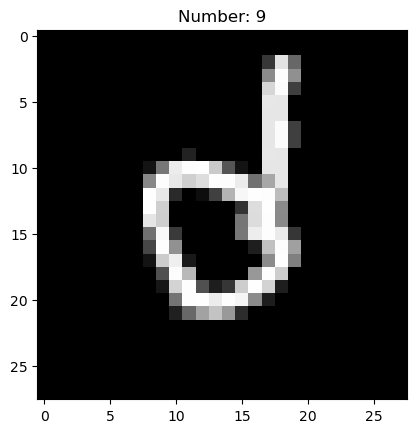

In [37]:
# Apply vertical flip on all images with a probability of 1 
# and convert the images to PyTorch tensors
transform_flipped = transforms.Compose([transforms.RandomVerticalFlip(p=1), transforms.ToTensor()])

# Load the MNIST dataset.
trainset_flipped = datasets.MNIST('data/', download=True, train=True, transform=transform_flipped)
validset_flipped = datasets.MNIST('data/', download=True, train=False, transform=transform_flipped)

# Create a DataLoader for the training set.
trainloader_flipped = torch.utils.data.DataLoader(trainset_flipped, batch_size=BATCH_SIZE, shuffle=True)
validloader_flipped = torch.utils.data.DataLoader(validset_flipped, batch_size=BATCH_SIZE, shuffle=False)

# Sample plot
X, y = next(iter(trainloader_flipped))

# Plot the first image in the batch.
plt.imshow(X[0, 0, :, :], cmap="gray")
plt.title(f"Number: {y[0].item()}");

### 3.3 Train a model on flipped images

We are going to do 3 experiments:

**Experiment A** — How much does flipping hurt the original model?

**Experiment B** — Can a model trained on flipped images learn just as well?

**Experiment C** — Does training on flipped images hurt performance on normal images?


### Experiment A — Testing the Original Model on Flipped Data

In [38]:
def evaluate(model, validloader):
    correct = 0
    total = 0
    
    with torch.no_grad():                        # no gradient needed
        for X, y in validloader:                 # loop through batches
            y_hat = model(X)                     # forward pass
            _, predicted = torch.softmax(y_hat, dim=1).topk(1, dim=1)  # get predicted label
            correct += (predicted.squeeze() == y).sum().item()          # count correct predictions
            total += y.size(0)                   # count total images
    
    accuracy = correct / total
    return accuracy

In [39]:
acc_normal = evaluate(model, validloader_normal)
acc_flipped = evaluate(model, validloader_flipped)

print(f"Original model on Normal data:  {acc_normal:.2%}")
print(f"Original model on Flipped data: {acc_flipped:.2%}")

Original model on Normal data:  98.46%
Original model on Flipped data: 37.11%



To investigate how sensitive our CNN is to image orientation, we evaluated the original model 
(trained on normal MNIST images) on a vertically flipped version of the validation set. 
The results revealed a dramatic drop in performance: from **98.46%** on normal images down 
to **37.11%** on flipped images, a decrease of over 60 percentage points. Although 37.11% is 
still well above random guessing (10% for a 10-class problem), this sharp decline suggests that 
the model did not learn the abstract shapes of digits, but rather memorized position-specific 
pixel patterns. In other words, the CNN learned *where* features appear in a normal image, 
not *what* those features fundamentally look like. This is a known limitation of CNNs trained 
without data augmentation. They tend to be sensitive to transformations such as flips, 
rotations, and shifts that were not present during training. In the next experiment, we will 
train a fresh model exclusively on flipped images to investigate whether a CNN can learn 
flipped digits just as effectively as normal ones.

### Experiment B & C — Training a Fresh Model on Flipped Data

In [40]:
# Fresh model 
model_flipped = MNIST_classifier()

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_flipped.parameters())

# Train on flipped data
results_flipped = trainer(model_flipped, criterion, optimizer, trainloader_flipped, validloader_flipped)

Epoch 1: Train Loss: 0.245. Valid Loss: 0.097. Valid Accuracy: 0.97.
Epoch 2: Train Loss: 0.081. Valid Loss: 0.061. Valid Accuracy: 0.98.
Epoch 3: Train Loss: 0.057. Valid Loss: 0.059. Valid Accuracy: 0.98.
Epoch 4: Train Loss: 0.044. Valid Loss: 0.049. Valid Accuracy: 0.98.
Epoch 5: Train Loss: 0.036. Valid Loss: 0.040. Valid Accuracy: 0.99.


In [41]:
acc_flipped_on_flipped = evaluate(model_flipped, validloader_flipped)
acc_flipped_on_normal  = evaluate(model_flipped, validloader_normal)

print(f"Flipped model on Flipped data: {acc_flipped_on_flipped:.2%}")
print(f"Flipped model on Normal data:  {acc_flipped_on_normal:.2%}")

Flipped model on Flipped data: 98.59%
Flipped model on Normal data:  37.62%


To complete the experiment, we trained a fresh CNN model exclusively on vertically flipped 
MNIST images and evaluated it on both the flipped and normal validation sets. The results 
were strikingly symmetric — the flipped model achieved **98.59%** accuracy on flipped images, 
nearly identical to the original model's **98.46%** on normal images, confirming that a CNN 
can learn flipped digits just as effectively as normal ones. However, when tested on normal 
images, the flipped model collapsed to **37.62%** — almost exactly mirroring the original 
model's **37.11%** on flipped images. This perfect symmetry reveals two fundamental insights 
about CNNs: first, they are agnostic to orientation during training and can learn any 
consistent set of patterns equally well; second, they are highly sensitive to **distribution 
shift** — a mismatch between training and test data distributions. The model does not learn 
an abstract understanding of digits; it learns the specific visual patterns present in its 
training data. A practical solution to this limitation is **data augmentation**, where both 
normal and flipped images are included during training, forcing the model to learn 
orientation-invariant features.

### Experiment D — Data Augmentation to Fix Distribution Shift

In [42]:
# 50% chance of flipping each image during training
transform_augmented = transforms.Compose([
    transforms.RandomVerticalFlip(p=0.5),
    transforms.ToTensor()
])

# Training set with augmentation
trainset_augmented = datasets.MNIST('data/', download=True, train=True, transform=transform_augmented)
trainloader_augmented = torch.utils.data.DataLoader(trainset_augmented, batch_size=BATCH_SIZE, shuffle=True)

# Validation sets — we keep both normal and flipped to test generalization
# validloader_normal and validloader_flipped already exist from before

In [44]:
# Fresh model 
model_augmented = MNIST_classifier()

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_augmented.parameters())

# Train on augmented data
results_augmented = trainer(model_augmented, criterion, optimizer, 
                            trainloader_augmented, validloader_normal)


Epoch 1: Train Loss: 0.381. Valid Loss: 0.189. Valid Accuracy: 0.94.
Epoch 2: Train Loss: 0.162. Valid Loss: 0.131. Valid Accuracy: 0.96.
Epoch 3: Train Loss: 0.117. Valid Loss: 0.136. Valid Accuracy: 0.95.
Epoch 4: Train Loss: 0.094. Valid Loss: 0.095. Valid Accuracy: 0.97.
Epoch 5: Train Loss: 0.078. Valid Loss: 0.088. Valid Accuracy: 0.97.


In [45]:
acc_augmented_on_normal  = evaluate(model_augmented, validloader_normal)
acc_augmented_on_flipped = evaluate(model_augmented, validloader_flipped)

print(f"Augmented model on Normal data:  {acc_augmented_on_normal:.2%}")
print(f"Augmented model on Flipped data: {acc_augmented_on_flipped:.2%}")

Augmented model on Normal data:  97.14%
Augmented model on Flipped data: 97.33%


To address the orientation sensitivity revealed in the previous experiments, we trained a 
new model using **data augmentation** — specifically, applying a random vertical flip with 
probability `p=0.5` to each training image. This means each image has a 50% chance of being 
flipped during every epoch, forcing the model to learn features that are invariant to 
orientation. The results confirmed that data augmentation effectively resolved the problem — 
the augmented model achieved **97.14%** on normal images and **97.33%** on flipped images, 
compared to the original model's **98.46%** and **37.11%** respectively. Notably, there was 
a small tradeoff of approximately 1.3 percentage points on normal images — a classic 
**bias-variance tradeoff** where the model becomes slightly less specialized in exchange for 
significantly better generalization. This experiment demonstrates that data augmentation is 
a simple yet powerful technique for making CNNs robust to real-world variations in input 
data, and should be considered a standard step in any image classification pipeline.

### Plots

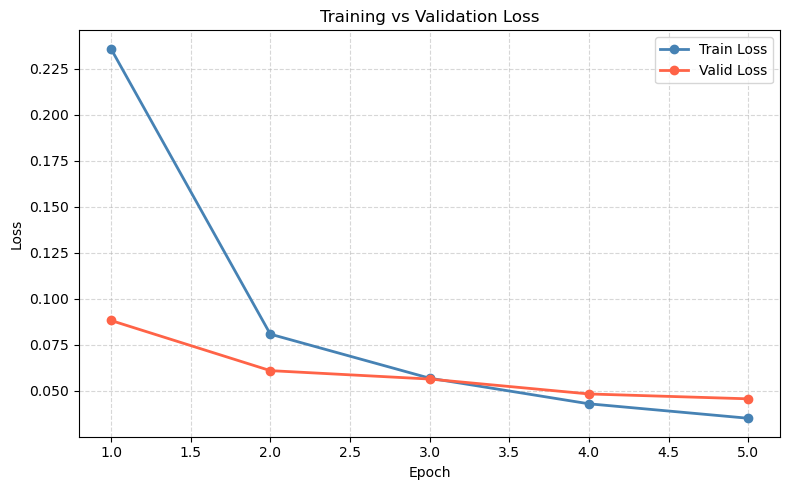

In [83]:
# Loss curve plot
epochs_list = [1, 2, 3, 4, 5]

plt.figure(figsize=(8, 5))  
plt.plot(epochs_list, results['train_loss'], label='Train Loss', marker='o',color='steelblue', linewidth=2)
plt.plot(epochs_list, results['valid_loss'], label='Valid Loss', marker='o', color='tomato', linewidth=2)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)  
plt.tight_layout()

plt.savefig('figures/loss_curve.png', dpi=150)  
plt.show()

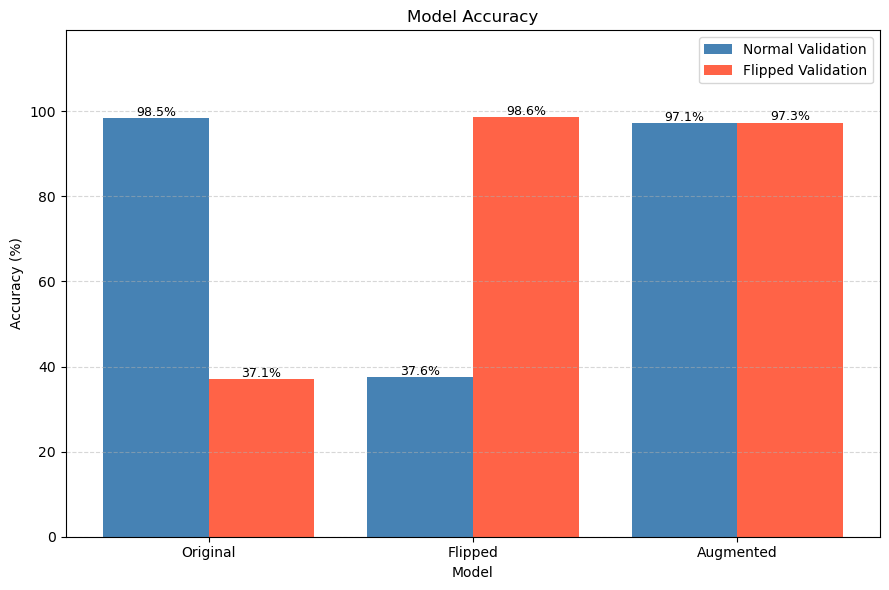

In [84]:
# Data organized by validation type
models = ['Original', 'Flipped', 'Augmented']
normal_acc  = [98.46, 37.62, 97.14]
flipped_acc = [37.11, 98.59, 97.33]

# X positions for the 3 groups
x = np.arange(len(models))

plt.figure(figsize=(9, 6))

# Plot grouped bars side by side
bars1 = plt.bar(x - 0.2, normal_acc,  width=0.4, label='Normal Validation',  color='steelblue')
bars2 = plt.bar(x + 0.2, flipped_acc, width=0.4, label='Flipped Validation', color='tomato')

# Add accuracy numbers on top of each bar
for bar in bars1:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{bar.get_height():.1f}%', ha='center', fontsize=9)
for bar in bars2:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{bar.get_height():.1f}%', ha='center', fontsize=9)

plt.xlabel('Model')
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy')
plt.xticks(x, models)
plt.ylim(0, 119)  
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig('figures/experiment_results.png', dpi=150)
plt.show()

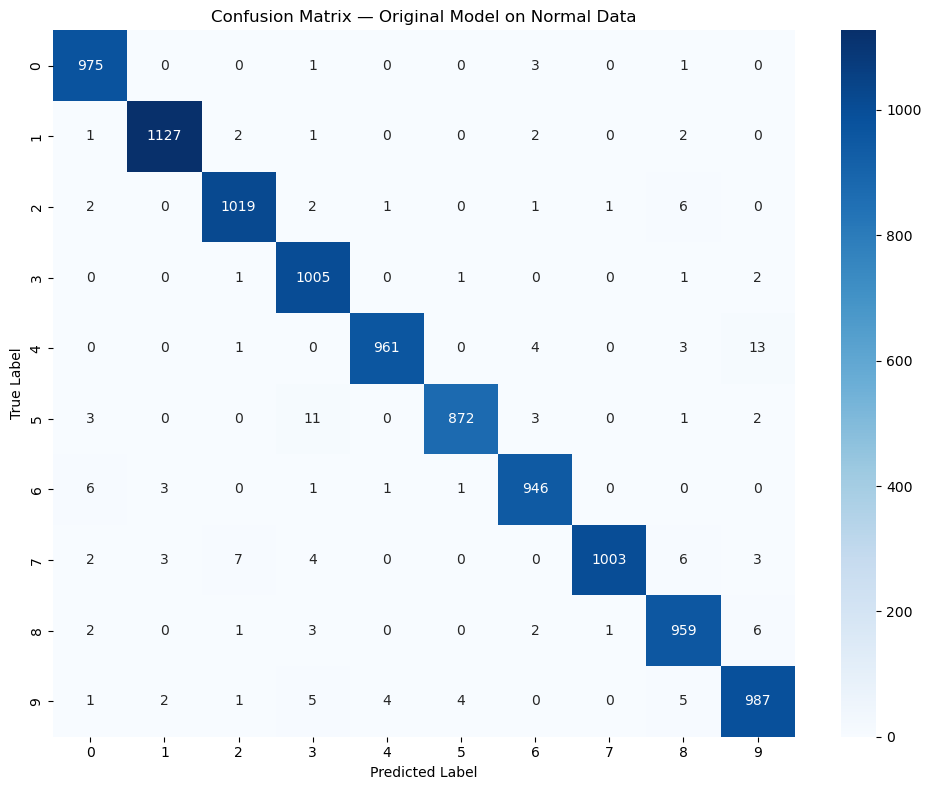

In [ ]:
# Collect all predictions and true labels
all_preds  = []
all_labels = []

with torch.no_grad():
    for X, y in validloader_normal:
        y_hat = model(X)
        _, predicted = torch.softmax(y_hat, dim=1).topk(1, dim=1)
        all_preds.extend(predicted.squeeze().tolist())  
        all_labels.extend(y.tolist())                   

# Build and plot confusion matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10),
            yticklabels=range(10))

plt.title('Confusion Matrix — Original Model on Normal Data')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()

plt.savefig('figures/confusion_matrix.png', dpi=150)
plt.show()